 Loaded trained policy weights.

Final DQN Portfolio Value:    $74010.89
Final Buy & Hold Value:       $71151.49
Final S&P 500 Value:          $16067.72
DQN Sharpe Ratio (Test Set):  0.0376
Buy & Hold Sharpe Ratio:      0.0388
S&P 500 Sharpe Ratio:         0.0187


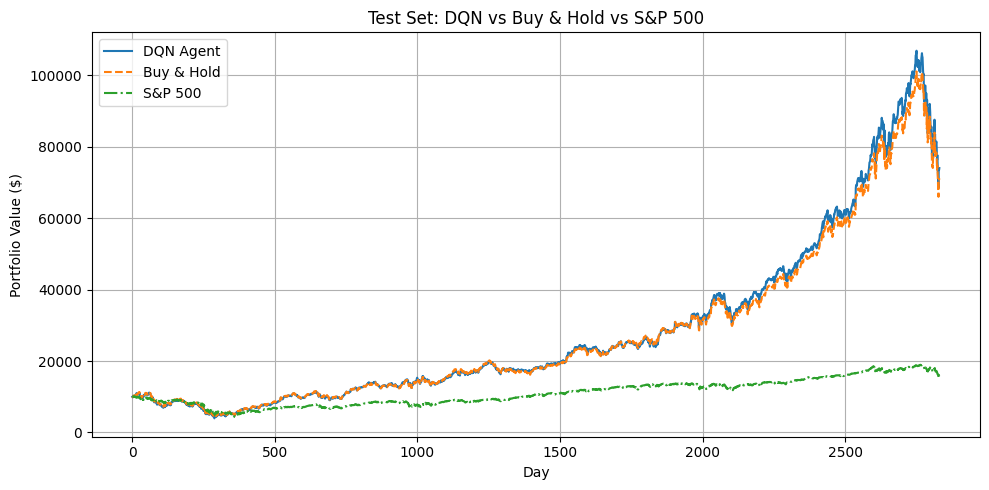

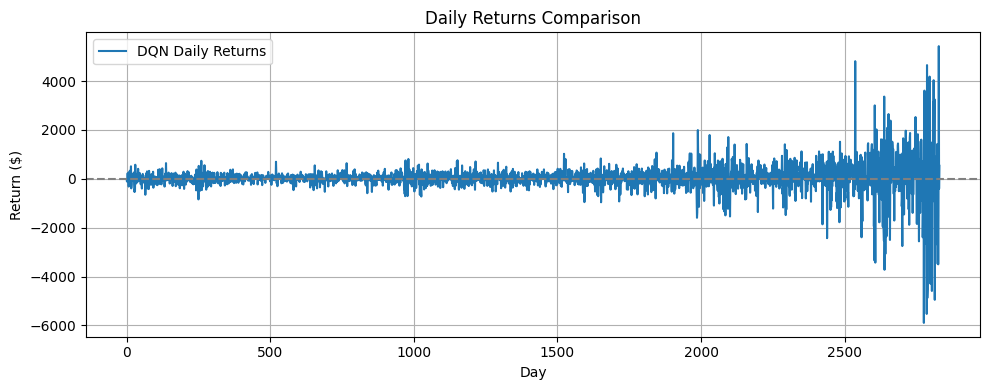

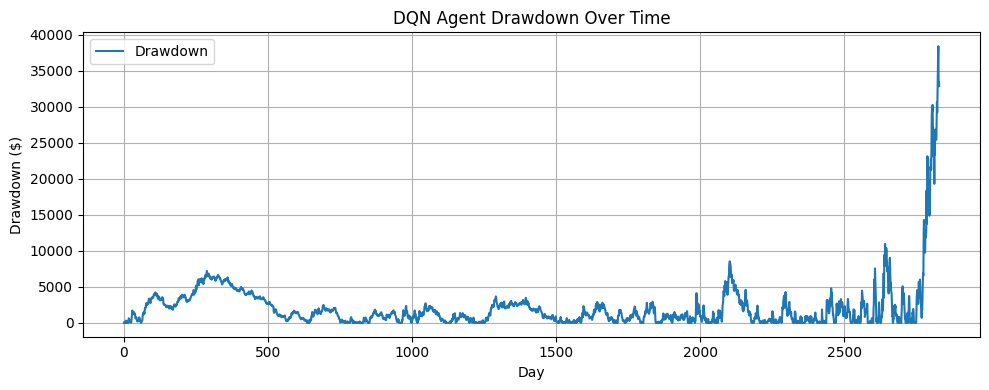

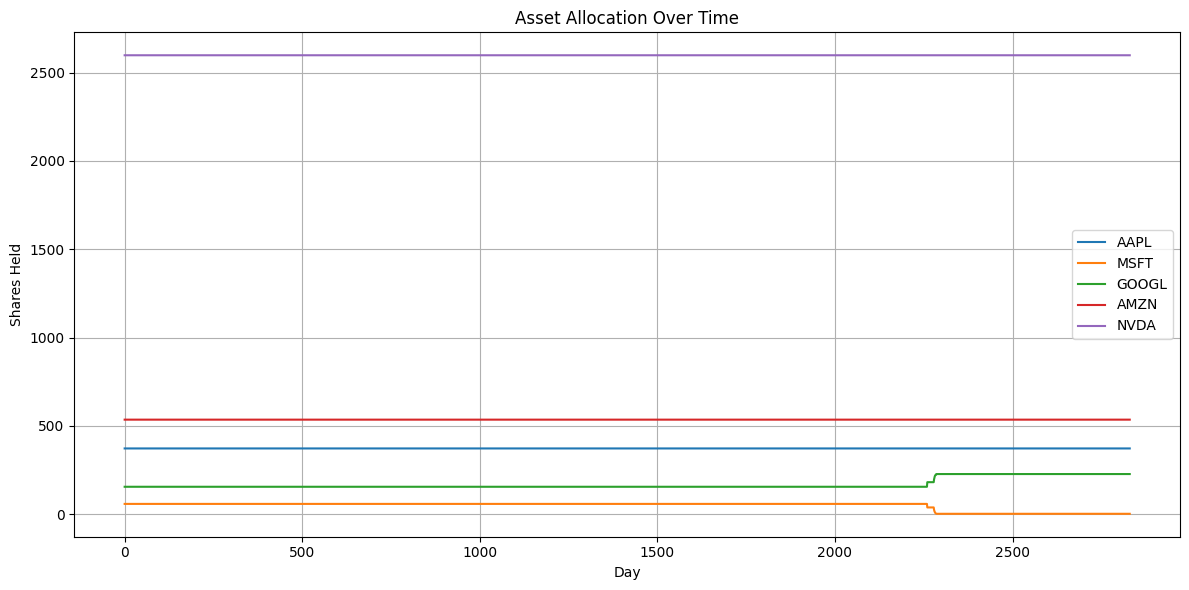

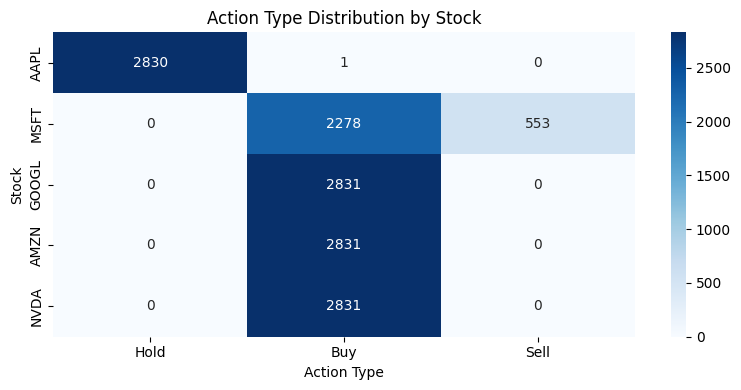

In [25]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from multi_stock_env import MultiStockEnv
from dqn_agent import DQNAgent
import torch

# --- Utility to decode actions ---
def decode_action_vector(action_vector, num_actions_per_stock):
    decoded = []
    for a in action_vector:
        action_type = a // 5   # 0=hold, 1=buy, 2=sell
        qty_level = (a % 5) + 1  # 1 to 5
        decoded.append((action_type, qty_level))
    return decoded

# --- Evaluation Function ---
def evaluate(agent, env, benchmark_path):
    state = env.reset()
    dqn_values = []
    bh_values = []
    dqn_returns = []
    bh_returns = []
    sp500_returns = []
    asset_allocations = []
    action_log = []

    # Buy & Hold setup
    init_price = env.stock_prices[0]
    shares = (env.initial_investment / env.num_stocks) / init_price

    # Benchmark: S&P 500
    benchmark_df = pd.read_csv(benchmark_path, index_col=0, parse_dates=True)
    sp500_prices = benchmark_df['Close'].values

    if len(sp500_prices) != env.stock_prices.shape[0]:
        raise ValueError("Benchmark and environment date ranges do not match")

    sp500_values = env.initial_investment * (sp500_prices / sp500_prices[0])

    done = False
    prev_val = env.get_portfolio_value()
    prev_bh = np.sum(shares * init_price)
    prev_sp = sp500_values[0]

    while not done:
        action_vector = agent.select_action(state)
        state, reward, done, info = env.step(action_vector)
        current_val = env.get_portfolio_value()
        dqn_values.append(current_val)
        dqn_returns.append(current_val - prev_val)
        prev_val = current_val

        bh_val = np.sum(shares * env.stock_prices[env.cur_step])
        bh_values.append(bh_val)
        bh_returns.append(bh_val - prev_bh)
        prev_bh = bh_val

        sp_val = sp500_values[env.cur_step]
        sp500_returns.append(sp_val - prev_sp)
        prev_sp = sp_val

        asset_allocations.append(env.stock_owned.copy())
        action_log.append(action_vector)

    # Sharpe ratios
    sharpe_dqn = np.mean(dqn_returns) / (np.std(dqn_returns) + 1e-6)
    sharpe_bh = np.mean(bh_returns) / (np.std(bh_returns) + 1e-6)
    sharpe_sp = np.mean(sp500_returns) / (np.std(sp500_returns) + 1e-6)

    drawdowns = [max(dqn_values[:i+1]) - val for i, val in enumerate(dqn_values)]

    print(f"\nFinal DQN Portfolio Value:    ${dqn_values[-1]:.2f}")
    print(f"Final Buy & Hold Value:       ${bh_values[-1]:.2f}")
    print(f"Final S&P 500 Value:          ${sp500_values[-1]:.2f}")
    print(f"DQN Sharpe Ratio (Test Set):  {sharpe_dqn:.4f}")
    print(f"Buy & Hold Sharpe Ratio:      {sharpe_bh:.4f}")
    print(f"S&P 500 Sharpe Ratio:         {sharpe_sp:.4f}")

    # Plot portfolio values
    plt.figure(figsize=(10, 5))
    plt.plot(dqn_values, label='DQN Agent')
    plt.plot(bh_values, label='Buy & Hold', linestyle='--')
    plt.plot(sp500_values, label='S&P 500', linestyle='-.')
    plt.xlabel('Day')
    plt.ylabel('Portfolio Value ($)')
    plt.title('Test Set: DQN vs Buy & Hold vs S&P 500')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    # Plot daily returns
    plt.figure(figsize=(10, 4))
    plt.plot(dqn_returns, label='DQN Daily Returns')
    plt.axhline(0, color='gray', linestyle='--')
    plt.xlabel('Day')
    plt.ylabel('Return ($)')
    plt.title('Daily Returns Comparison')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    # Plot drawdown
    plt.figure(figsize=(10, 4))
    plt.plot(drawdowns, label='Drawdown')
    plt.xlabel('Day')
    plt.ylabel('Drawdown ($)')
    plt.title('DQN Agent Drawdown Over Time')
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot asset allocation over time
    asset_allocations = np.array(asset_allocations)
    plt.figure(figsize=(12, 6))
    for i in range(env.num_stocks):
        plt.plot(asset_allocations[:, i], label=env.symbols[i])
    plt.xlabel('Day')
    plt.ylabel('Shares Held')
    plt.title('Asset Allocation Over Time')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    # Action distribution heatmap (decoded)
    action_counts = np.zeros((env.num_stocks, 3))
    for vector in action_log:
        decoded = decode_action_vector(vector, agent.num_actions_per_stock)
        for i, (a_type, _) in enumerate(decoded):
            action_counts[i, a_type] += 1

    plt.figure(figsize=(8, 4))
    sns.heatmap(action_counts, annot=True, fmt='g', cmap='Blues', 
                xticklabels=['Hold', 'Buy', 'Sell'], yticklabels=env.symbols)
    plt.xlabel('Action Type')
    plt.ylabel('Stock')
    plt.title('Action Type Distribution by Stock')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA']

    test_env = MultiStockEnv(
        symbols=tickers,
        data_dir="stock_data/test",
        reward_type="raw"
    )

    agent = DQNAgent(
        state_dim=test_env.state_dim,
        num_stocks=len(tickers)
    )

    #  Load trained weights
    agent.policy_net.load_state_dict(torch.load("models/dqn_trained.pth"))
    agent.policy_net.eval()  # disable dropout, etc., for evaluation
    print(" Loaded trained policy weights.")

    agent.epsilon = 0.0  # Force greedy policy during evaluation

    benchmark_file = "stock_data/benchmark/^GSPC_prices.csv"

    evaluate(agent, test_env, benchmark_file)
